### In this notebook the scores of 8 selected metrics are calculated and ranked for the reactions in 18 strychnine synthetic pathways. The scores obtained along the results of prediction from the notebook sinkOrSourceClassification are also ranked.

Firstly, the necessairy libraries, packages and modules are imported.

In [1]:
from rdkit.Chem import inchi
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import  Draw
from rdkit.Chem import rdChemReactions
from rdkit.Chem.SpacialScore import SPS
from rdkit.Chem import rdFingerprintGenerator
import os
import sys
from rdkit import RDConfig
from rdkit.Chem import Descriptors

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

splitReaction divides the reactions and returns the reactants and products of the reaction in the pathway separated.

In [4]:
def splitReactions(reactions):
    reactants = []
    products = []
    for rxn in reactions:
        parts =  rxn.split(">")
        if parts[0] == "":
            print("There are no reactants for ths reaction.\n")
            continue
        if parts[-1] == "":
            print("There are no products for ths reaction.\n")
            continue
        #reacts = react.split(".")
        mol = Chem.MolFromSmiles(parts[0])
        if mol is None: 
            print("Invalid SMILES.\n")
        reactants.append(mol)
        #prods = prod.split(".")
        molp = Chem.MolFromSmiles(parts[-1])
        if mol is None: 
            print("Invalid SMILES.\n")
        products.append(molp)
    return reactants, products

In the following cell the functions for metrics scores computations are established. They take as input data and getFpNorm and getnSPScore take also heavy atom count of the data. Each of them returns an array of scores determinated based on the input data.

In [5]:
def getSAScore(data):
    scores = []
    for i in data:
        scores.append(sascorer.calculateScore(i))
    print(len(scores))
    return scores

def getnSPS(data):
    nsps = []
    for i in data:
        nsps.append(SPS(i, normalize = True))
    return nsps

def getSPS(data):
    nsps = []
    for i in data:
        nsps.append(SPS(i, normalize = False))
    return nsps

def getHAC(data):
    hac = []
    for i in data:
        hac.append(i.GetNumAtoms())
    return hac

def getnSAScore(dataSA, dataHAC):
    nSA = []
    for i in range(0, len(dataSA)):
        nSA.append(dataSA[i]/dataHAC[i])
    return nSA

def getFpNorm(data, hac):
    generateFp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    normBit = []
    for i in range(0, len(data)):
        normBit.append(generateFp.GetFingerprint(data[i]).GetNumOnBits()/hac[i])
    return normBit


def getDeltas(reactants, products):
    deltas = []
    for i in range(0,len(reactants)):
        deltas.append(products[i] - reactants[i])
    return deltas

def getBertz(data):
    bertz = []
    for i in data:
        bertz.append(Descriptors.BertzCT(i))
    return bertz

def getMC1(data):
    mc1 = []
    for i in data:
        numDivalent = sum(1 for atom in i.GetAtoms()
                         if atom.GetDegree()==2)
        mc1.append(1-(numDivalent/(i.GetNumAtoms())))
    return mc1

getDeltas calculates and returns the differential of the value of the score for the reactant and for the product.

getRankings returns and prints the values in ascending order alongside their index in the original array.

In [6]:
def getDeltas(reactants, products):
    deltas = []
    for i in range(0,len(reactants)):
        deltas.append(products[i] - reactants[i])
    return deltas
    
def getRankings(res, metric):
    resArr = []
    for i in range(0, len(res)):
        resArr.append([i+1, res[i]])
    resArr.sort(key = lambda x: x[1])
    print("..................",metric,"...................")
    for i in resArr:
        print (i[0], i[1])
    return resArr

In the following cells the score for all of the metrics for each pathway is calculated along the deltas for each reaction and their ranking.

In [7]:
reactions = []
with open("woodward.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAW = getDeltas(rSAScore, pSAScore)
nSAW = getDeltas(rnSAScore, pnSAScore)
spsW = getDeltas(rsps, psps)
nspsW = getDeltas(rnsps, pnsps)
hacW = getDeltas(rhac, phac)
fpW = getDeltas(rfpNorm, pfpNorm)
bertzW = getDeltas(rBertz, pBertz)
mc1W = getDeltas(rMc1, pMc1)

SAScoreW = getRankings(SAW, "SA")
nSAScoreW = getRankings(nSAW, "nSA")
spsW = getRankings(spsW, "sps")
nspsW = getRankings(nspsW, "nsps")
hacW  = getRankings(hacW, "hac")
fpW = getRankings(fpW, "fps")
bertzW = getRankings(bertzW, "bertz")
mc1W = getRankings(mc1W, "mc1")

29
29
.................. SA ...................
11 -0.5575462312206723
27 -0.2656435792038536
4 -0.17792991588641804
5 -0.1533780219780212
17 -0.1383829926316027
25 -0.057948024948024646
13 -0.05127182338211078
20 0.0036890996959622058
14 0.029497283785842043
22 0.037489092817013514
28 0.03769544189449725
12 0.0667068471459249
16 0.06907773561033892
9 0.07215577512172278
18 0.07424416625517072
21 0.08183961199788214
1 0.08186785022039267
29 0.08906110382492471
19 0.1356238782187793
15 0.1602561397137352
8 0.16034421761868156
26 0.24741080049202235
3 0.2850087494653586
2 0.28536181384953174
10 0.4832684554274902
24 0.4882892895826014
6 0.5306171819814001
23 0.644259067499414
7 1.3737884191608227
.................. nSA ...................
16 -0.038372624413119547
27 -0.034609513350942284
13 -0.019564493537135685
21 -0.014766207481824417
14 -0.008746546430389274
5 -0.006971728271728234
9 -0.006083232283307677
2 -0.003788717534794553
25 -0.002228770190308621
6 -0.0006121977075996543
11 -0.

In [8]:
reactions = []
with open("magnus.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAM = getDeltas(rSAScore, pSAScore)
nSAM = getDeltas(rnSAScore, pnSAScore)
spsM = getDeltas(rsps, psps)
nspsM = getDeltas(rnsps, pnsps)
hacM = getDeltas(rhac, phac)
fpM = getDeltas(rfpNorm, pfpNorm)
bertzM = getDeltas(rBertz, pBertz)
mc1M = getDeltas(rMc1, pMc1)

SAScoreM = getRankings(SAM, "SA")
nSAScoreM = getRankings(nSAM, "nSA")
spsM = getRankings(spsM, "sps")
nspsM = getRankings(nspsM, "nsps")
hacM  = getRankings(hacM, "hac")
fpM = getRankings(fpM, "fps")
bertzM = getRankings(bertzM, "bertz")
mc1M = getRankings(mc1M, "mc1")

28
28
.................. SA ...................
23 -0.6684734315362277
2 -0.5609790424524785
9 -0.5369301966641649
4 -0.2218322292327386
18 -0.17260915653166542
16 -0.16857882473090946
12 -0.1630460120627788
28 -0.15686377221360281
26 -0.10859978770190715
22 -0.04265399129172831
8 -0.012375934971107228
15 0.0
17 0.008146075332400748
21 0.018459796806967965
25 0.03987327935222673
13 0.11549980599174603
5 0.12111723823105258
20 0.15238990069829317
11 0.16925759185868472
24 0.1990063597804781
3 0.21165987282741128
27 0.29581463216223014
19 0.3672325982961526
14 0.42003830201231995
6 0.6371471584516204
1 0.6953736890915874
10 0.7364570431995991
7 1.213312595552022
.................. nSA ...................
16 -0.07270388196717648
5 -0.03336782973180476
28 -0.026726145186226208
1 -0.024670104260687636
24 -0.022532249574173407
2 -0.015317601618122886
8 -0.012124762147171203
3 -0.007981703415007771
20 -0.005138522532962375
23 -0.005061112910381582
19 -0.004579382916584329
22 -0.00115281057545

In [36]:
reactions = []
with open("kuehne.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAK = getDeltas(rSAScore, pSAScore)
nSAK = getDeltas(rnSAScore, pnSAScore)
spsK = getDeltas(rsps, psps)
nspsK = getDeltas(rnsps, pnsps)
hacK = getDeltas(rhac, phac)
fpK = getDeltas(rfpNorm, pfpNorm)
bertzK = getDeltas(rBertz, pBertz)
mc1K = getDeltas(rMc1, pMc1)

rSAScoreK = getRankings(SAK, "SA")
rnSAScoreK = getRankings(nSAK, "nSA")
rspsK = getRankings(spsK, "sps")
rnspsK = getRankings(nspsK, "nsps")
rhacK  = getRankings(hacK, "hac")
rfpK = getRankings(fpK, "fps")
rbertzK = getRankings(bertzK, "bertz")
rmc1K = getRankings(mc1K, "mc1")

18
18
.................. SA ...................
3 -0.48090755755373316
4 -0.23837051251418195
7 -0.12564254471608738
14 -0.10511668820653775
5 -0.10157994441373219
15 -0.09761215009579338
10 -0.022011992089748134
13 -0.017292125570142147
1 0.04258552737957544
12 0.06373533795572506
16 0.0705559671914866
18 0.08906110382492471
17 0.09028090374609476
11 0.11786680480249778
9 0.3784772801698679
8 0.950646067307372
2 1.138560652761175
6 2.1747492596207554
.................. nSA ...................
1 -0.07890625786612739
10 -0.05053566773453241
13 -0.04801884233133774
3 -0.038934970460572066
16 -0.03264009534464696
15 -0.004244006525904065
4 0.0015096067718281952
12 0.0026556390814885256
18 0.003562444152997002
7 0.009665413190987293
9 0.016455533920429033
5 0.01700132780252349
17 0.020036799352211115
2 0.03955129237270727
11 0.04450515734609359
6 0.04551016056700717
14 0.0530102935031487
8 0.07915293917229274
.................. sps ...................
14 -223
3 -94
5 -85
15 -73
7 -47
4 -46

In [10]:
reactions = []
with open("overman.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAO = getDeltas(rSAScore, pSAScore)
nSAO = getDeltas(rnSAScore, pnSAScore)
spsO = getDeltas(rsps, psps)
nspsO = getDeltas(rnsps, pnsps)
hacO = getDeltas(rhac, phac)
fpO = getDeltas(rfpNorm, pfpNorm)
bertzO = getDeltas(rBertz, pBertz)
mc1O = getDeltas(rMc1, pMc1)

SAScoreO = getRankings(SAO, "SA")
nSAScoreO = getRankings(nSAO, "nSA")
spsO = getRankings(spsO, "sps")
nspsO = getRankings(nspsO, "nsps")
hacO  = getRankings(hacO, "hac")
fpO = getRankings(fpO, "fps")
bertzO = getRankings(bertzO, "bertz")
mc1O = getRankings(mc1O, "mc1")

24
24
.................. SA ...................
6 -0.29042115507257105
18 -0.258127319616559
20 -0.22923101846132
12 -0.18986704078245253
24 -0.15686377221360281
3 -0.13640158446135775
14 -0.04098330563085728
5 -0.038134186347684285
9 -0.006507611820939729
17 -0.005480575070470728
22 0.0
15 0.03941380239467218
11 0.05751763925729225
13 0.07850029633246347
2 0.11908362543821038
8 0.134442251805444
7 0.13653979122857773
19 0.23539471896426178
4 0.25253891446126886
23 0.2601075079599404
21 0.3897552048463293
1 0.4479862713802989
10 0.6196216840835032
16 0.6482414262944021
.................. nSA ...................
5 -0.10577081606672739
1 -0.07459397528534079
7 -0.028582094160433752
24 -0.026726145186226208
15 -0.021365891375765222
13 -0.013479492802057041
8 -0.012997276069026925
18 -0.012477839406628694
6 -0.011170044425868109
9 -0.010885464321133492
19 -0.009978179059065506
22 0.0
11 0.001337619517611452
3 0.0026451927750427984
2 0.005412892065373209
10 0.012042713395069071
14 0.0146163

In [11]:
reactions = []
with open("rawal.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAR = getDeltas(rSAScore, pSAScore)
nSAR = getDeltas(rnSAScore, pnSAScore)
spsR = getDeltas(rsps, psps)
nspsR = getDeltas(rnsps, pnsps)
hacR = getDeltas(rhac, phac)
fpR = getDeltas(rfpNorm, pfpNorm)
bertzR= getDeltas(rBertz, pBertz)
mc1R = getDeltas(rMc1, pMc1)

SAScoreR = getRankings(SAR, "SA")
nSAScoreR = getRankings(nSAR, "nSA")
spsR = getRankings(spsR, "sps")
nspsR = getRankings(nspsR, "nsps")
hacR  = getRankings(hacR, "hac")
fpR = getRankings(fpR, "fps")
bertzR = getRankings(bertzR, "bertz")
mc1R = getRankings(mc1R, "mc1")

15
15
.................. SA ...................
7 -1.1803377451454313
4 -0.29871552422169323
14 -0.07118114900116979
3 -0.03484900082701792
6 0.0032496647410322765
8 0.047630769230771364
15 0.08906110382492471
11 0.12417474831165531
2 0.2289024291497963
5 0.2289735191946427
1 0.31927156016947045
9 0.3474673981050378
12 0.3619626656860664
13 0.7456151278984038
10 1.0728117150750363
.................. nSA ...................
7 -0.40899140997662486
12 -0.07958848576633587
3 -0.059421649405083515
4 -0.014935776211084661
1 -0.002713007380612281
9 0.00027462446101962634
15 0.003562444152997002
8 0.004330069930070124
2 0.016350173510699728
6 0.01816911074390795
5 0.02582148131780687
13 0.027996944816567393
10 0.035760390502501196
14 0.04707228833348279
11 0.08076435560975134
.................. sps ...................
14 -120
11 -43
4 -40
5 -27
6 -20
8 -5
2 5
9 44
7 52
3 80
13 129
1 132
15 161
12 232
10 388
.................. nsps ...................
12 -7.6636363636363605
4 -2.0
3 -1.22857142

In [12]:
reactions = []
with open("kuehne98.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAK8 = getDeltas(rSAScore, pSAScore)
nSAK8 = getDeltas(rnSAScore, pnSAScore)
spsK8 = getDeltas(rsps, psps)
nspsK8 = getDeltas(rnsps, pnsps)
hacK8 = getDeltas(rhac, phac)
fpK8 = getDeltas(rfpNorm, pfpNorm)
bertzK8 = getDeltas(rBertz, pBertz)
mc1K8 = getDeltas(rMc1, pMc1)

SAScoreK8 = getRankings(SAK8, "SA")
nSAScoreK8 = getRankings(nSAK8, "nSA")
spsK8 = getRankings(spsK8, "sps")
nspsK8 = getRankings(nspsK8, "nsps")
hacK8  = getRankings(hacK8, "hac")
fpK8 = getRankings(fpK8, "fps")
bertzK8 = getRankings(bertzK8, "bertz")
mc1K8 = getRankings(mc1K8, "mc1")

21
21
.................. SA ...................
9 -0.450142630217627
15 -0.2991953387834698
4 -0.20506983468912932
12 -0.1848585605212758
21 -0.15686377221360281
10 -0.07243334388085376
5 -0.060681141441493835
13 -0.04074609401334506
19 0.0
7 0.027673851097161695
17 0.07471023937358545
8 0.1044441226008912
16 0.12221276229076139
20 0.2601075079599404
11 0.26012042760233545
18 0.3897552048463293
2 0.41858883578535
1 0.5343364866841416
3 0.5801828397034479
14 1.093348132494489
6 1.5324956949218826
.................. nSA ...................
1 -0.048307204153135955
16 -0.027892587845031264
21 -0.026726145186226208
11 -0.009690725095997138
2 -0.009677828369738073
3 -0.00626128247868056
12 -0.005601774561250772
9 -0.005156931312602725
19 0.0
10 0.0024181748353902244
4 0.003893513473185062
7 0.004933821762066082
13 0.007052454340557401
8 0.007641256606686797
18 0.015590208193853178
17 0.01826325522947303
5 0.020140120136048684
6 0.02577293187913443
20 0.03085589461607971
14 0.0410028892040119

In [13]:
reactions = []
with open("bosch.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAB = getDeltas(rSAScore, pSAScore)
nSAB = getDeltas(rnSAScore, pnSAScore)
spsB = getDeltas(rsps, psps)
nspsB = getDeltas(rnsps, pnsps)
hacB = getDeltas(rhac, phac)
fpB = getDeltas(rfpNorm, pfpNorm)
bertzB = getDeltas(rBertz, pBertz)
mc1B = getDeltas(rMc1, pMc1)

SAScoreB = getRankings(SAB, "SA")
nSAScoreB = getRankings(nSAB, "nSA")
spsB = getRankings(spsB, "sps")
nspsB = getRankings(nspsB, "nsps")
hacB  = getRankings(hacB, "hac")
fpB = getRankings(fpB, "fps")
bertzB = getRankings(bertzB, "bertz")
mc1B = getRankings(mc1B, "mc1")

14
14
.................. SA ...................
6 -0.4189769174428273
2 -0.34161665074862047
14 -0.15686377221360281
3 -0.04622984209274694
12 0.0
7 0.09971509865222306
5 0.13604808032651583
10 0.23056222126646464
13 0.2601075079599404
8 0.42120112778388563
4 0.46319974012634546
9 0.5737531279139976
11 0.5779386948306424
1 0.9863476843086456
.................. nSA ...................
8 -0.06843535760341912
14 -0.026726145186226208
1 -0.02426007525971352
10 -0.020403878624569993
5 -0.008677865224579001
4 -0.0035381313289751526
12 0.0
3 0.008765664157057984
2 0.010056623884355353
6 0.019426832673955508
13 0.03085589461607971
11 0.04472520704091004
7 0.05219412833550366
9 0.06804671166946397
.................. sps ...................
6 -170
7 -73
3 -72
12 0
9 25
2 49
4 55
11 64
13 77
14 79
5 99
10 115
8 232
1 312
.................. nsps ...................
8 -4.6381578947368425
4 -1.6620689655172427
3 -0.7555555555555564
10 -0.7321428571428541
14 -0.5582608695652169
12 0.0
6 0.19125000000

In [14]:
reactions = []
with open("volhardt.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAV = getDeltas(rSAScore, pSAScore)
nSAV = getDeltas(rnSAScore, pnSAScore)
spsV = getDeltas(rsps, psps)
nspsV = getDeltas(rnsps, pnsps)
hacV = getDeltas(rhac, phac)
fpV = getDeltas(rfpNorm, pfpNorm)
bertzV = getDeltas(rBertz, pBertz)
mc1V = getDeltas(rMc1, pMc1)

SAScoreV = getRankings(SAV, "SA")
nSAScoreV = getRankings(nSAV, "nSA")
spsV = getRankings(spsV, "sps")
nspsV = getRankings(nspsV, "nsps")
hacV  = getRankings(hacV, "hac")
fpV = getRankings(fpV, "fps")
bertzV = getRankings(bertzV, "bertz")
mc1V = getRankings(mc1V, "mc1")

13
13
.................. SA ...................
5 -0.8143601150082898
1 -0.3401204554097923
10 -0.04246404682274196
12 -0.018815395576512906
13 0.05185536841142291
7 0.12313389557892496
3 0.15676583759093
2 0.17248759264311708
9 0.2504438090452856
4 0.3450857142857142
11 0.6451929025293897
8 0.702657349122048
6 1.2070227375404903
.................. nSA ...................
1 -0.30201707082081664
5 -0.19541555021900844
9 -0.08768024875647765
2 -0.062009649918792514
10 -0.0012867892976588524
13 0.002074214736456914
11 0.024939491000450342
4 0.03137142857142855
7 0.03231516677513435
8 0.03513286745610242
6 0.04086871956784041
12 0.04903426831287147
3 0.11424453705393478
.................. sps ...................
12 -120
3 -69
7 -28
10 0
4 1
2 62
11 65
1 69
5 104
8 145
9 232
13 241
6 389
.................. nsps ...................
9 -7.348484848484848
5 -0.2424242424242422
3 -0.24064171122994615
10 0.0
4 0.09090909090908994
2 0.5588235294117645
1 1.0
7 2.5978260869565233
11 2.94223484848484

In [38]:
reactions = []
with open("martin.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAMA = getDeltas(rSAScore, pSAScore)
nSAMA = getDeltas(rnSAScore, pnSAScore)
spsMA = getDeltas(rsps, psps)
nspsMA = getDeltas(rnsps, pnsps)
hacMA = getDeltas(rhac, phac)
fpMA = getDeltas(rfpNorm, pfpNorm)
bertzMA = getDeltas(rBertz, pBertz)
mc1MA = getDeltas(rMc1, pMc1)

rSAScoreMA = getRankings(SAMA, "SA")
rnSAScoreMA = getRankings(nSAMA, "nSA")
rspsMA = getRankings(spsMA, "sps")
rnspsMA = getRankings(nspsMA, "nsps")
rhacMA  = getRankings(hacMA, "hac")
rfpMA = getRankings(fpMA, "fps")
rbertzMA = getRankings(bertzMA, "bertz")
rmc1MA = getRankings(mc1MA, "mc1")

15
15
.................. SA ...................
1 -0.5215848057751566
6 -0.24980660584914283
4 -0.17418074329998579
15 -0.15686377221360281
11 -0.12111538953822532
8 -0.01016195138232412
13 0.0
3 0.08432830746177267
5 0.0952191991816882
7 0.19631644730088915
14 0.2601075079599404
12 0.3897552048463293
2 0.5701837144588318
9 0.6983100921806296
10 0.811322197500524
.................. nSA ...................
1 -0.18883654048327023
15 -0.026726145186226208
7 -0.023872805515370313
6 -0.015615801544297758
4 -0.005443148228124556
3 -0.0012959289948654695
13 0.0
8 0.0033298023706439667
12 0.015590208193853178
9 0.01752317159294106
2 0.018393023047059087
10 0.02965283745959499
14 0.03085589461607971
5 0.037145276228121304
11 0.04197738724498207
.................. sps ...................
6 -163
11 -120
4 -81
5 -79
13 0
8 4
10 21
14 77
15 79
3 111
7 120
1 124
12 144
9 203
2 328
.................. nsps ...................
1 -12.972704714640198
6 -7.473846153846154
4 -2.53125
7 -1.421911421911421
1

In [16]:
reactions = []
with open("bodwell.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SABO = getDeltas(rSAScore, pSAScore)
nSABO = getDeltas(rnSAScore, pnSAScore)
spsBO = getDeltas(rsps, psps)
nspsBO = getDeltas(rnsps, pnsps)
hacBO = getDeltas(rhac, phac)
fpBO = getDeltas(rfpNorm, pfpNorm)
bertzBO = getDeltas(rBertz, pBertz)
mc1BO = getDeltas(rMc1, pMc1)

SAScoreBO = getRankings(SABO, "SA")
nSAScoreBO = getRankings(nSABO, "nSA")
spsBO = getRankings(spsBO, "sps")
nspsBO = getRankings(nspsBO, "nsps")
hacBO  = getRankings(hacBO, "hac")
fpBO = getRankings(fpBO, "fps")
bertzBO = getRankings(bertzBO, "bertz")
mc1BO = getRankings(mc1BO, "mc1")

12
12
.................. SA ...................
5 -0.3117236956704552
1 -0.2824609958808013
4 -0.2204718965240806
11 -0.07118114900116979
7 -0.0036112768757927682
2 0.05535047822267902
6 0.07501299236465009
12 0.08906110382492471
8 0.143737047293941
9 0.3619626656860664
10 0.7456151278984038
3 1.583624693190468
.................. nSA ...................
9 -0.07958848576633587
4 -0.046263208579999465
2 -0.02099311341543103
7 -0.008225444633490675
1 -0.0055030669046707
5 0.002774088963369531
6 0.003261434450636952
12 0.003562444152997002
10 0.027996944816567393
8 0.04430164230359562
11 0.04707228833348279
3 0.0826205351220202
.................. sps ...................
11 -120
8 -43
1 2
7 14
2 42
4 51
3 79
6 80
10 129
12 161
5 204
9 232
.................. nsps ...................
9 -7.6636363636363605
4 -1.312380952380952
7 -0.8206521739130466
2 -0.3803827751196174
1 0.9394736842105278
6 3.478260869565222
8 4.424999999999997
3 4.5432900432900425
11 4.886249999999997
10 4.957386363636363
1

In [17]:
reactions = []
with open("shibasaki.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAS = getDeltas(rSAScore, pSAScore)
nSAS = getDeltas(rnSAScore, pnSAScore)
spsS = getDeltas(rsps, psps)
nspsS = getDeltas(rnsps, pnsps)
hacS = getDeltas(rhac, phac)
fpS = getDeltas(rfpNorm, pfpNorm)
bertzS = getDeltas(rBertz, pBertz)
mc1S = getDeltas(rMc1, pMc1)

SAScoreS = getRankings(SAS, "SA")
nSAScoreS = getRankings(nSAS, "nSA")
spsS = getRankings(spsS, "sps")
nspsS = getRankings(nspsS, "nsps")
hacS  = getRankings(hacS, "hac")
fpS = getRankings(fpS, "fps")
bertzS = getRankings(bertzS, "bertz")
mc1S = getRankings(mc1S, "mc1")

31
31
.................. SA ...................
9 -0.618416398163042
27 -0.45410193319876235
6 -0.37231886972033124
18 -0.35084807450781064
11 -0.2509947962096506
20 -0.23270626605377398
3 -0.18771890299379734
31 -0.15686377221360281
29 -0.12217891827333549
24 -0.11992024928029821
16 -0.004941082900018046
14 0.0
7 0.009764619398197283
13 0.011334551911982516
28 0.033697902097901355
23 0.039267678567826536
25 0.04950193274499348
22 0.0775116839054153
30 0.13910485364591807
26 0.14454526590950234
15 0.19090916992227314
5 0.1990886353038004
1 0.2749992298688344
12 0.3432822373399489
8 0.3470337218622497
17 0.3583766681197922
10 0.3865659500558065
4 0.3900138301684013
2 0.6818051862417285
21 0.7015576906480625
19 1.4723159961092414
.................. nSA ...................
1 -0.20325646270965197
4 -0.09478769248286897
24 -0.06483580993816138
26 -0.05057104261065265
8 -0.03281544539055714
31 -0.026726145186226208
16 -0.02216753462185525
9 -0.008380951286724642
6 -0.00836433640941503
17 -0.

In [18]:
reactions = []
with open("mori.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAMORI = getDeltas(rSAScore, pSAScore)
nSAMORI = getDeltas(rnSAScore, pnSAScore)
spsMORI = getDeltas(rsps, psps)
nspsMORI = getDeltas(rnsps, pnsps)
hacMORI = getDeltas(rhac, phac)
fpMORI = getDeltas(rfpNorm, pfpNorm)
bertzMORI = getDeltas(rBertz, pBertz)
mc1MORI = getDeltas(rMc1, pMc1)

SAScoreMORI = getRankings(SAMORI, "SA")
nSAScoreMORI = getRankings(nSAMORI, "nSA")
spsMORI = getRankings(spsMORI, "sps")
nspsMORI = getRankings(nspsMORI, "nsps")
hacMORI  = getRankings(hacMORI, "hac")
fpMORI = getRankings(fpMORI, "fps")
bertzMORI = getRankings(bertzMORI, "bertz")
mc1MORI = getRankings(mc1MORI, "mc1")

22
22
.................. SA ...................
12 -0.3466698113469855
16 -0.2505217589018436
2 -0.2364517666826167
10 -0.1476064991895516
21 -0.07118114900116979
6 -0.04454719334719304
7 0.0436394416797361
4 0.06611009058743811
15 0.07331119756583426
9 0.07631912502324312
3 0.08187060063224472
22 0.08906110382492471
13 0.16135296220396267
17 0.21810421974706173
20 0.24986771031884736
14 0.25988777168882926
18 0.3142736344520092
5 0.33427789485297144
11 0.40976989454339297
19 0.41048521022169737
8 0.6318635624104507
1 1.7791486903255649
.................. nSA ...................
18 -0.08365234444266323
7 -0.028056486396542832
14 -0.025110232132648985
11 -0.011122255241677675
16 -0.009278583663031248
10 -0.004341367623222098
4 -0.0021742305210298435
6 -0.0017133535902766617
9 -0.0015668314184070775
3 0.0031488692550863395
22 0.003562444152997002
20 0.00780836594746398
15 0.00891836369310317
1 0.012989236657311443
12 0.01678235455694621
5 0.01757376842258407
19 0.01760487561583496
2 0.01

In [19]:
reactions = []
with open("fukuyama.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAF = getDeltas(rSAScore, pSAScore)
nSAF = getDeltas(rnSAScore, pnSAScore)
spsF = getDeltas(rsps, psps)
nspsF = getDeltas(rnsps, pnsps)
hacF = getDeltas(rhac, phac)
fpF = getDeltas(rfpNorm, pfpNorm)
bertzF = getDeltas(rBertz, pBertz)
mc1F = getDeltas(rMc1, pMc1)

SAScoreF = getRankings(SAF, "SA")
nSAScoreF = getRankings(nSAF, "nSA")
spsF = getRankings(spsF, "sps")
nspsF = getRankings(nspsF, "nsps")
hacF  = getRankings(hacF, "hac")
fpF = getRankings(fpF, "fps")
bertzF = getRankings(bertzF, "bertz")
mc1F = getRankings(mc1F, "mc1")

29
29
.................. SA ...................
6 -0.5331332559346595
16 -0.39457059795891336
11 -0.32977245880718176
20 -0.2288882189020196
4 -0.2268512150204014
19 -0.16915874377023332
29 -0.15686377221360281
8 -0.14816690414238298
23 -0.11662579094903514
10 -0.05416739495291534
14 -0.04609237049530801
3 -0.013827497246834852
18 0.0
27 0.0
22 0.005221313628806179
2 0.006982074488641743
25 0.07471023937358545
13 0.1320252356000804
12 0.1760793501153346
15 0.1766107545115556
28 0.2601075079599404
21 0.3325724515082058
17 0.3680159869452
26 0.3897552048463293
9 0.5798158632562123
24 0.6630454733261129
7 0.954745855113396
1 1.6779197388426663
5 2.387796923076925
.................. nSA ...................
11 -0.22680979444544558
6 -0.09156570516092943
2 -0.08111088698626448
8 -0.07428323961366631
3 -0.04753499964787469
29 -0.026726145186226208
17 -0.020131963222669358
15 -0.011180931170442582
23 -0.006839641628728091
20 -0.0052020049750458874
4 -0.004384081109019652
13 -0.0036219556955871

In [20]:
reactions = []
with open("padwa.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAP = getDeltas(rSAScore, pSAScore)
nSAP = getDeltas(rnSAScore, pnSAScore)
spsP = getDeltas(rsps, psps)
nspsP = getDeltas(rnsps, pnsps)
hacP = getDeltas(rhac, phac)
fpP = getDeltas(rfpNorm, pfpNorm)
bertzP = getDeltas(rBertz, pBertz)
mc1P = getDeltas(rMc1, pMc1)

SAScoreP = getRankings(SAP, "SA")
nSAScoreP = getRankings(nSAP, "nSA")
spsP = getRankings(spsP,"sps")
nspsP = getRankings(nspsP, "nsps")
hacP  = getRankings(hacP, "hac")
fpP = getRankings(fpP, "fps")
bertzP = getRankings(bertzP, "bertz")
mc1P = getRankings(mc1P, "mc1")

17
17
.................. SA ...................
3 -0.33857475340132126
12 -0.2032965035974108
17 -0.15686377221360281
13 -0.1536618641650005
8 -0.03484217741768347
7 -0.010306561513472978
9 -0.00037496618273280546
4 0.16655490627904612
15 0.2005001234284034
2 0.20249526952498087
6 0.20671254712368636
16 0.25592773866821705
1 0.28187939682915975
11 0.3825669076231053
10 0.4092936386038506
14 0.746691915247264
5 1.4882794206695387
.................. nSA ...................
11 -0.07999164697017733
12 -0.05559204027752945
17 -0.026726145186226208
4 -0.026122582684194276
1 -0.011524707355473271
13 -0.004390338976142882
2 -0.00374745917279265
15 -0.0032923258173269965
9 -1.4998647309333313e-05
8 0.005186356823870503
6 0.0071280188663339905
7 0.016661956294133223
3 0.016786475900152642
14 0.02589153833352434
5 0.05131998002308755
16 0.09942532811226543
10 0.10392195812540617
.................. sps ...................
10 -113
3 -95
13 -73
7 -43
16 -35
8 -14
2 33
15 61
1 72
6 73
17 79
4 93
9 98

In [21]:
reactions = []
with open("reissing.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SARE = getDeltas(rSAScore, pSAScore)
nSARE = getDeltas(rnSAScore, pnSAScore)
spsRE = getDeltas(rsps, psps)
nspsRE = getDeltas(rnsps, pnsps)
hacRE = getDeltas(rhac, phac)
fpRE = getDeltas(rfpNorm, pfpNorm)
bertzRE = getDeltas(rBertz, pBertz)
mc1RE = getDeltas(rMc1, pMc1)

SAScoreRE = getRankings(SARE, "SA")
nSAScoreRE = getRankings(nSARE, "nSA")
spsRE = getRankings(spsRE, "sps")
nspsRE = getRankings(nspsRE, "nsps")
hacRE  = getRankings(hacRE, "hac")
fpRE = getRankings(fpRE, "fps")
bertzRE = getRankings(bertzRE, "bertz")
mc1RE = getRankings(mc1RE, "mc1")

10
10
.................. SA ...................
5 -0.15466994296710368
4 -0.14726319753368156
9 -0.07118114900116979
1 0.030529713745947262
10 0.08906110382492471
6 0.143737047293941
7 0.3619626656860664
3 0.5186925780637344
8 0.7456151278984038
2 1.667700382664501
.................. nSA ...................
7 -0.07958848576633587
4 -0.04212449310644145
5 0.0012361602690955653
10 0.003562444152997002
1 0.005127012024752395
8 0.027996944816567393
3 0.03387067548161696
6 0.04430164230359562
9 0.04707228833348279
2 0.08981900815260664
.................. sps ...................
5 -167
9 -120
6 -43
1 7
4 43
3 125
8 129
10 161
7 232
2 528
.................. nsps ...................
7 -7.6636363636363605
5 -5.365000000000002
4 -5.2361904761904725
1 0.6692307692307704
6 4.424999999999997
9 4.886249999999997
8 4.957386363636363
10 6.440000000000005
3 7.658008658008654
2 25.41818181818182
.................. hac ...................
9 -7
6 -4
2 -3
1 -1
3 -1
5 -1
8 -1
10 0
4 4
7 13
.................

In [22]:
reactions = []
with open("andrade.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAA = getDeltas(rSAScore, pSAScore)
nSAA = getDeltas(rnSAScore, pnSAScore)
spsA = getDeltas(rsps, psps)
nspsA = getDeltas(rnsps, pnsps)
hacA = getDeltas(rhac, phac)
fpA = getDeltas(rfpNorm, pfpNorm)
bertzA = getDeltas(rBertz, pBertz)
mc1A = getDeltas(rMc1, pMc1)

SAScoreA = getRankings(SAA, "SA")
nSAScoreA = getRankings(nSAA, "nSA")
spsA = getRankings(spsA, "sps")
nspsA = getRankings(nspsA, "nsps")
hacA  = getRankings(hacA, "hac")
fpA = getRankings(fpA, "fps")
bertzA = getRankings(bertzA, "bertz")
mc1A = getRankings(mc1A, "mc1")

15
15
.................. SA ...................
6 -0.643468696760559
9 -0.4884969861889026
15 -0.15686377221360281
13 -0.09323987095568143
4 0.15373162393162332
14 0.2601075079599404
5 0.3493246666785339
12 0.3618796862637854
10 0.3873036421715481
7 0.406459861976483
11 0.4369369625913073
1 0.4602158653846171
8 0.5184072653238383
2 0.6745263968755122
3 1.1179143298035523
.................. nSA ...................
2 -0.11433308812161891
10 -0.07742866330265771
15 -0.026726145186226208
7 -0.015228322643414838
6 -0.006299048071865765
5 0.0012045857428004125
4 0.0054904151404151225
12 0.011308740195743294
11 0.018307830341133896
8 0.020458688360894345
14 0.03085589461607971
1 0.04183780594405609
3 0.04375922282277234
13 0.04625885524309195
9 0.06961282104195984
.................. sps ...................
9 -208
13 -120
6 -21
1 0
4 0
8 0
5 25
11 65
14 77
15 79
7 108
12 144
10 232
2 242
3 413
.................. nsps ...................
10 -6.186363636363634
7 -1.9191919191919204
5 -0.99285714

In [23]:
reactions = []
with open("vanderwal.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAVA = getDeltas(rSAScore, pSAScore)
nSAVA = getDeltas(rnSAScore, pnSAScore)
spsVA = getDeltas(rsps, psps)
nspsVA = getDeltas(rnsps, pnsps)
hacVA = getDeltas(rhac, phac)
fpVA = getDeltas(rfpNorm, pfpNorm)
bertzVA = getDeltas(rBertz, pBertz)
mc1VA = getDeltas(rMc1, pMc1)

SAScoreVA = getRankings(SAVA, "SA")
nSAScoreVA = getRankings(nSAVA, "nSA")
spsVA = getRankings(spsVA, "sps")
nspsVA = getRankings(nspsVA, "nsps")
hacVA  = getRankings(hacVA, "hac")
fpVA = getRankings(fpVA, "fps")
bertzVA = getRankings(bertzVA, "bertz")
mc1VA = getRankings(mc1VA, "mc1")

8
8
.................. SA ...................
5 -0.9217920251654288
8 -0.15686377221360281
6 -0.08451018692019918
1 0.1241520568965786
7 0.881847983558349
2 0.9252533997137746
4 1.6469493820163184
3 1.7509290684101586
.................. nSA ...................
5 -0.14439750516092942
8 -0.026726145186226208
1 -0.024712192926329396
2 0.00399317408041483
4 0.013400050447453848
6 0.021159099714761764
7 0.07053435920157236
3 0.07303195925722272
.................. sps ...................
5 -78
6 -25
1 31
8 79
2 80
4 179
7 253
3 549
.................. nsps ...................
5 -10.21111111111111
8 -0.5582608695652169
1 -0.08333333333333393
2 0.7619047619047628
6 3.0931899641577054
7 16.256038647342997
4 17.77777777777778
3 24.435064935064936
.................. hac ...................
6 -4
7 -4
3 1
5 1
8 2
1 3
4 3
2 6
.................. fps ...................
5 -0.5444444444444447
2 -0.15238095238095273
8 -0.09739130434782606
6 0.01433691756272415
7 0.106280193236715
1 0.1166666666666667
3 0

In [24]:
reactions = []
with open("macmillian.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SAMM = getDeltas(rSAScore, pSAScore)
nSAMM = getDeltas(rnSAScore, pnSAScore)
spsMM = getDeltas(rsps, psps)
nspsMM = getDeltas(rnsps, pnsps)
hacMM = getDeltas(rhac, phac)
fpMM = getDeltas(rfpNorm, pfpNorm)
bertzMM = getDeltas(rBertz, pBertz)
mc1MM = getDeltas(rMc1, pMc1)

SAScoreMM = getRankings(SAMM, "SA")
nSAScoreMM = getRankings(nSAMM, "nSA")
spsMM = getRankings(spsMM, "sps")
nspsMM = getRankings(nspsMM, "nsps")
hacMM  = getRankings(hacMM, "hac")
fpMM = getRankings(fpMM, "fps")
bertzMM = getRankings(bertzMM, "bertz")
mc1MM = getRankings(mc1MM, "mc1")

12
12
.................. SA ...................
12 -0.15686377221360281
5 -0.13594277563992652
9 -0.004022789234992885
1 0.06262419983656642
7 0.08094237979562635
6 0.1105212393671895
2 0.14594832322447182
11 0.36742726519809565
8 0.42238349957805177
3 0.4600615558115919
10 0.9149157562576455
4 1.2965655044044313
.................. nSA ...................
1 -0.031333101415745315
12 -0.026726145186226208
8 -0.023015467487567748
6 -0.010776028106543281
2 0.002312032151365828
5 0.003331951469454336
3 0.009445711691933326
9 0.018225438318089704
7 0.030269383539814884
4 0.03293750880443644
10 0.03294480141631645
11 0.08338223824022906
.................. sps ...................
11 -111
2 -66
9 -44
5 -30
7 -17
3 37
6 51
12 79
1 101
8 140
10 302
4 401
.................. nsps ...................
8 -2.702359346642467
2 -2.666666666666666
1 -1.25
6 -1.1805555555555571
12 -0.5582608695652169
3 0.4479166666666661
5 0.492647058823529
9 2.342902711323763
7 4.771072796934867
11 9.603260869565219
10 10

The data from the prediction in the sinkOrSourceClassification notebook are then also sorted using getRankings.

In [25]:
woodward = [4.43281850e-03, 5.60605251e-03, 5.34101032e-04, 4.76738438e-03,
 2.06016803e-04, 5.64802135e-03, 2.96481945e-03, 7.06935118e-03,
 4.68428453e-03, 2.11278546e-02, 9.37845964e-03, 1.04200667e-02,
 1.97690686e-02, 3.20615774e-03, 4.95236034e-03, 3.53639298e-04,
 6.49106960e-02, 4.89194103e-03, 5.25947679e-03, 1.30080446e-02,
 3.58260766e-03, 5.00760157e-04, 7.59462760e-04, 2.76203602e-02,
 7.92602933e-02, 1.54799758e-02, 4.12319323e-02, 2.23029828e-01,
 2.83526778e-01]

magnus = [7.74717868e-02, 1.32146433e-02, 2.85534896e-02, 2.23776836e-03,
 1.55455650e-03, 5.83107481e-03, 4.85026663e-02, 1.11284849e-01,
 1.41627715e-04, 1.58321252e-02, 1.44659530e-03, 9.94941644e-03,
 4.07131188e-02, 3.69912007e-02, 5.69247127e-02, 1.29398352e-01,
 5.07383662e-01, 2.57741302e-01, 7.65987353e-01, 7.62348956e-01,
 3.20924073e-01, 7.74958412e-01, 7.79640225e-01, 8.36599827e-01,
 6.79191774e-01, 3.18602305e-01, 3.14952562e-01, 2.98933030e-01]

kuehne = [1.32389687e-03, 1.91139478e-03, 6.53309109e-03, 4.02772602e-03,
 4.59585007e-02, 6.56659676e-02, 6.19955155e-04, 1.88678716e-03,
 2.77352293e-02, 1.78320093e-01, 1.30016883e-02, 1.56981176e-02,
 8.88544314e-02, 3.13779064e-02, 7.34760055e-02, 7.72809063e-01,
 9.08886392e-02, 2.83526778e-01]

overman = [0.00518902, 0.02064209, 0.01285196, 0.01135459, 0.36417921, 0.04298845,
 0.05735221, 0.00586229, 0.03403884, 0.07252024, 0.01342813, 0.00060438,
 0.0020117,  0.00797815, 0.00264748, 0.00061053, 0.01083871, 0.02905346,
 0.1383822,  0.46609701, 0.48974793, 0.40155699, 0.14564568, 0.29893303]

rawal = [8.81339999e-03, 7.45120806e-04, 6.13377967e-01, 8.78042166e-03,
 2.04842737e-01, 6.27964372e-02, 3.26596462e-02, 1.01522467e-01,
 8.37625863e-01, 4.02304367e-02, 1.74781399e-02, 7.58434841e-02,
 1.42680483e-01, 5.68092738e-01, 2.83526778e-01]

kuehne98 = [6.65079503e-03, 3.11239036e-04, 1.77462865e-02, 2.34206160e-02,
 1.30921805e-02, 1.30317415e-02, 1.92807679e-03, 2.15357650e-04,
 6.70004269e-04, 8.72114228e-04, 3.05660136e-03, 8.39921950e-04,
 2.78500243e-04, 3.39637412e-03, 1.12390142e-01, 1.82967752e-01,
 4.77376471e-02, 4.89747929e-01, 4.01556992e-01, 1.45645684e-01,
 2.98933030e-01]

bosch = [0.00842776, 0.08132005, 0.19194284, 0.21017032, 0.12205647, 0.08207245,
 0.02638036, 0.04253454, 0.03030703, 0.16452457, 0.41256746, 0.40155699,
 0.14564568, 0.29893303]

volhardt = [2.75887563e-01, 3.13460077e-02, 4.68680457e-03, 4.99228551e-03,
 3.49409127e-02, 4.55093874e-04, 9.35395747e-04, 8.20671209e-03,
 1.06868281e-01, 8.37128716e-03, 2.81174084e-02, 6.24913143e-01,
 3.24261020e-01]

martin = [0.24435131, 0.01203943, 0.01327461, 0.0197145,  0.00319578, 0.00090761,
 0.00491823, 0.02999395, 0.07777244, 0.04174967, 0.5957208,  0.48974793,
 0.40155699, 0.14564568, 0.29893303]

bodwell = [0.70728945, 0.83328826, 0.00095422, 0.68676335, 0.23886382, 0.07217233,
 0.10024953, 0.00155677, 0.07584348, 0.14268048, 0.56809274, 0.28352678]

shibasaki = [0.03703637, 0.86595832, 0.52987797, 0.68888363, 0.16132095, 0.10524854,
 0.0108174,  0.19216289, 0.00210773, 0.0188412, 0.01522621, 0.00740325,
 0.00259609, 0.00577863, 0.00961461, 0.00266234, 0.0041994,  0.0014634,
 0.00258884, 0.02129112, 0.00818484, 0.16363921, 0.01486652, 0.94456463,
 0.11798095, 0.95753913, 0.39021008, 0.236056,   0.17823638, 0.6328323,
 0.29893303]

mori = [0.93587966, 0.74777473, 0.83589051, 0.95986529, 0.55167569, 0.60877448,
 0.95748358, 0.7561621,  0.14516406, 0.54909516, 0.49098072, 0.15910617,
 0.20149301, 0.15842371, 0.02685031, 0.17507434, 0.0047858,  0.04542291,
 0.07654001, 0.51622279, 0.56809274, 0.28352678]

fukuyama = [1.52128252e-03, 8.22397600e-01, 4.21873924e-01, 7.51685231e-01,
 9.03152167e-01, 1.17136343e-02, 4.02155691e-02, 1.19776015e-01,
 5.47494708e-03, 1.61873421e-01, 6.85259492e-01, 7.98315251e-01,
 7.36988872e-01, 7.79551729e-01, 3.90888759e-01, 2.12286601e-02,
 4.34552091e-02, 2.49365926e-03, 4.40974861e-04, 1.73526205e-04,
 1.54982103e-04, 1.46943770e-04, 3.53758061e-04, 3.57170394e-04,
 4.77376471e-02, 4.89747929e-01, 4.01556992e-01, 1.45645684e-01,
 2.98933030e-01]

padwa = [4.56362121e-03, 1.07530679e-01, 3.22851593e-02, 8.35719707e-03,
 8.60901591e-02, 2.73684496e-01, 2.37521921e-02, 8.52412972e-04,
 4.82911464e-04, 1.08682085e-04, 6.97566764e-02, 3.04749951e-02,
 5.58464624e-03, 1.84316007e-02, 3.69752860e-01, 2.65973570e-02,
 2.98933030e-01]

reissing = [0.43603924, 0.01401588, 0.00186449, 0.00802795, 0.00149932, 0.00155677,
 0.07584348, 0.14268048, 0.56809274, 0.28352678]

andrade = [3.72041177e-03, 1.61584868e-02, 3.08032217e-04, 9.26955164e-04,
 5.82539639e-04, 3.59348731e-02, 1.12565313e-03, 1.00269510e-03,
 1.28678538e-03, 3.67579988e-01, 9.21449052e-02, 4.55624390e-01,
 2.13791497e-01, 1.45645684e-01, 2.98933030e-01]

vanderwaal = [0.39393792, 0.00076663, 0.00062255, 0.03164919, 0.0207493,  0.00355639,
 0.01729767, 0.29893303]

macmillian = [1.65531129e-01, 3.28792781e-03, 2.79533464e-03, 5.30142199e-04,
 7.95836145e-03, 9.99548604e-03, 1.86642064e-03, 6.75333485e-04,
 3.84942693e-05, 4.68668883e-04, 8.17722872e-03, 2.98933030e-01]


W = getRankings(woodward, "woodward")
M = getRankings(magnus, "magnus")
K = getRankings(kuehne, "kuhene")
O = getRankings(overman, "onverman")
R = getRankings(rawal, "rawal")
K98 = getRankings(kuehne98, "kuehne98")
B = getRankings(bosch, "bosch")
V = getRankings(volhardt, "volhardt")
MA = getRankings(martin, "martin")
BO = getRankings(bodwell, "bodwell")
S = getRankings(shibasaki, "shibasaki")
MORI = getRankings(mori, "mori")
F = getRankings(fukuyama, "fukuyama")
P = getRankings(padwa, "padwa")
RE = getRankings(reissing, "reissing")
A = getRankings(andrade, "andrade")
VW = getRankings(vanderwaal, "vandewaal")
MM = getRankings(macmillian, "macmillian")



.................. woodward ...................
5 0.000206016803
16 0.000353639298
22 0.000500760157
3 0.000534101032
23 0.00075946276
7 0.00296481945
14 0.00320615774
21 0.00358260766
1 0.0044328185
9 0.00468428453
4 0.00476738438
18 0.00489194103
15 0.00495236034
19 0.00525947679
2 0.00560605251
6 0.00564802135
8 0.00706935118
11 0.00937845964
12 0.0104200667
20 0.0130080446
26 0.0154799758
13 0.0197690686
10 0.0211278546
24 0.0276203602
27 0.0412319323
17 0.064910696
25 0.0792602933
28 0.223029828
29 0.283526778
.................. magnus ...................
9 0.000141627715
11 0.0014465953
5 0.0015545565
4 0.00223776836
6 0.00583107481
12 0.00994941644
2 0.0132146433
10 0.0158321252
3 0.0285534896
14 0.0369912007
13 0.0407131188
7 0.0485026663
15 0.0569247127
1 0.0774717868
8 0.111284849
16 0.129398352
18 0.257741302
28 0.29893303
27 0.314952562
26 0.318602305
21 0.320924073
17 0.507383662
25 0.679191774
20 0.762348956
19 0.765987353
22 0.774958412
23 0.779640225
24 0.836599827
....

In [33]:
def normalize(scores):
    minimum = min(scores)
    maximum = max(scores)
    normalized = []
    for i in scores:
        normalized.append((i-minimum)/(maximum-minimum))
    return normalized

Finally a plot of some of the metrics over some pathways is made.

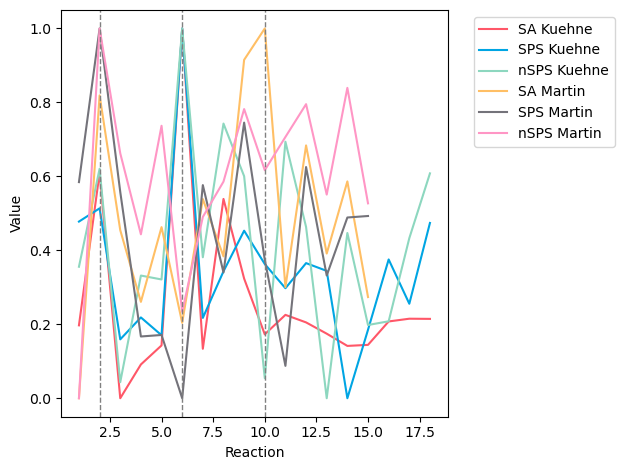

In [42]:
import matplotlib.pyplot as plt
x = list(range(1, len(SAK)+1))
x1 = list(range(1, len(SAMA)+1))
plt.plot(x, normalize(SAK), color ='#FF5768', label = "SA Kuehne")
plt.plot(x, normalize(spsK), color = '#00A5E3', label = "SPS Kuehne")
plt.plot(x, normalize(nspsK), color = '#8DD7BF', label = "nSPS Kuehne")
plt.plot(x1, normalize(SAMA), color = '#FFBF65', label = "SA Martin")
plt.plot(x1, normalize(spsMA), color = '#74737A', label = "SPS Martin")
plt.plot(x1, normalize(nspsMA), color = '#FF96C5', label = "nSPS Martin")
plt.axvline(x=6, linestyle = '--', color = 'grey', linewidth = 1)
plt.axvline(x=2, linestyle = '--', color = 'grey', linewidth = 1)
plt.axvline(x=10, linestyle = '--', color = 'grey', linewidth = 1)
plt.xlabel("Reaction")
plt.ylabel("Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("K+Mpreds.png")
plt.show()

